# Cyclophilin D Binding-Mode Family Analysis

This notebook is the analysis code for the protein–ligand interaction fingerprint (PLIF) binding-mode analysis in *High-Throughput Crystallographic Fragment Screening of Cyclophilin D: A Structural Atlas and Resource for Inhibitor Discovery* (Gebauer *et al.*). It takes the fragment-bound CypD structures and:


1. groups individual ligand poses into **binding-mode families** by the interactions they make with CypD (Fig. 3A),
2. reports the residue–interaction pairs that define each family (Fig. 3B), and
3. measures how chemically similar the fragments within each family are (Fig. S3B).

The main result is that each family shares a well-defined interaction pattern but has low chemical similarity (median Morgan Tanimoto < 0.3). Binding geometry at these sites is dictated by the CypD surface rather than by a clear fixed chemistry, which makes the families useful starting points for scaffold hopping and fragment merging.

## Approach

- **PLIFs.** Interaction fingerprints were computed in MOE for every resolved complex, with a 0.5 kcal/mol cutoff for an interaction to count. Many crystal structures contain several binding events across chains A, B and X, so the raw per-complex PLIF is split into **one fingerprint per ligand pose** using the ligand atom → (residue, chain) map. Pose IDs have the form `x0022-0` (crystal ID-pose index).
- **Fingerprint encoding.** Each bit is one (residue UID, interaction type) pair observed anywhere in the dataset. Residue numbers are shifted by +42 to match CypD numbering (`RUID_CORRECTION`). Poses with fewer than 2 interactions (`MIN_INTS = 2`) are removed. This is to increase the signal observed in the dataset caused by potentially spurious binidng mddes. 
- **Family assignment.** Ligand poses and interaction bits form a bipartite graph. A pose is linked to every bit it contains, and only bits shared by at least 5 poses (`hub_threshold = 5`) are kept, which removes one-off interactions. Families are the seven largest communities found by Clauset–Newman–Moore greedy modularity maximization (NetworkX). Poses outside these communities are labeled `Unassigned`.
- **Chemical diversity.** For each family, pairwise Tanimoto similarity is computed on RDKit Morgan fingerprints (radius 2, 2,048 bits) and summarized as quartiles.

## Notebook sections

| Section | What it does |
|---|---|
| Load Molecular Data | Loads the renumbered CypD reference structure and residue map |
| Fragment Binding Fingerprint Assembly | Parses MOE PLIFs, splits them per ligand pose, builds and filters binary fingerprints |
| Molecule Data Structure Assembly | Loads superposed ligand SDFs (per complex and per pose) |
| Binding Mode Family Bipartite Graph | Constructs the graph structure for neighborhood coloring to effeciently and transparently identify binding mode families  |
| Interactive Cluster Exploration | 3D view of a chosen family in the CypD pocket (`py3Dmol`), and per-family SMILES / crystal ID table |
| Morgan similarity heatmaps | Within-family Tanimoto matrices with Q1/median/Q3 |
| PLIF Cluster Summary | Frequency of each residue–interaction pair within each family (Fig. 3B) |

## Inputs (`data/`)

- `cypd_renumbered.pdb`, `cypd_reference_superpose.pdb`: CypD reference structures, the latter in a specific reference frame for ligand comparison. 
- `040126_mol_prepared_plifs_w_atom.csv`: MOE PLIFs with ligand atom maps
- `mol_prepared_superpose_lig_all.tar.xz` - the ligand poses extracted from the minimized and prepared complexes.
- `mol_superpose_lig_sep.tar.xz` - each pose within a complex is a different file (i.e. CypD-x0877-pandda-model-2)
  - Useful for visualization, as not each pose binds in the same place, allows honest visualization of families at per pose level.


## Outputs

- `my_molecular_network_colored.html`: interactive family network
- `ind_clusts_graph/<family>/`: SDFs of the poses in each family
- `processed_data/cluster_mol_members.xlsx`, `processed_data/per_cluster_plifs.xlsx`: family membership and per-family PLIF tables
- `final_figures/all_cluster_morgan_sim.png`, `final_figures/cluster_plifs.pdf`: figure panels

Helper functions live in the local `utils/` package (`graphs`, `metrics`, `mol`, `plif`). The notebook was run with Python 3.10.19 using RDKit, ProDy, NetworkX, pyvis, py3Dmol, pandas, SciPy and seaborn.

# Data Analysis

In [1]:
import tarfile
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import prody as pr
import seaborn as sns
from networkx.algorithms import community as nx_community
from pyvis.network import Network
from rdkit import Chem
from tqdm import tqdm

from utils.graphs import (
    cmap_hex,
    get_indices_from_bit_array,
    heatmap,
    standardize_graph,
)

from utils.mol import (
    mols_to_2d_tile_image,
    morgan_similarity_matrix,
    save_mol_to_sdf,
    visualize_complex,
)
from utils.plif import (
    PLIF_TYPES,
    build_interaction_mapping,
    make_all_ruid_type,
    make_fps,
)

In [2]:
%load_ext autoreload
%autoreload 2

## Load Molecular Data 
Read the PDB file and essemble helper maps for identifying residues and RUIDs (residue unique identifier)

In [3]:
pdb = pr.parsePDB("./data/cypd_renumbered.pdb")
residues = list(pdb.iterResidues())
res_names = [res.getResname() for res in residues]
ruids = [res.getResnum() for res in residues]
uid_res_map = {int(ruid): str(res_name) for ruid, res_name in zip(ruids, res_names)}

In [4]:
MIN_INTS = 2
RUID_CORRECTION = (
    42  # CypD starts at 43 - Ser 0 on X chain , Chains A and B start at rUID 1
)

## Fragment Binding Fingerprint Assembly

In the below cell, the Protein Ligand Interaction Fingerprints (PLIFs) are assembled by reading in a csv that contains:
* The ID of the crystal structure (i.e. CypD-x0022-pandda-model) 
* The raw vector for the PLIF (`PLIF RAW` field)
* As there can be multiple binding events per structure there is a vector in the `mol_prepared_lig_all_atom_extract` that is a list of 3 member tuples that pair the *atom number*, *residue number* and *chain number* to identify which atoms belong to specific ligands. 

The resulting dataframe now contains the field `lig_sep_plifs` that stratifies the PLIFS by ligand, as the original form computed them for all ligands in the complex

In [5]:
# Read csvs with plifs
frag_plifs_df = pd.read_csv("data/040126_mol_prepared_plifs_w_atom.csv")
plif_atom_labels = {
    y.split("-")[1]: [
        np.array(eval(str(x).replace(" ", ",")) if isinstance(x, str) else []).T
    ]
    for _, x, y in frag_plifs_df[
        ["mol_prepared_lig_all_atom_extract", "xid"]
    ].itertuples()
}
# atom, residue, chain
plif_atom_df = pd.DataFrame.from_dict(plif_atom_labels, orient="index")
plif_atom_df = plif_atom_df.reset_index()
plif_atom_df.columns = ["xid_short", "atom_maps"]


# Convert string vectors to python datatypes
frag_plifs = [eval(x.replace(" ", ",")) for x in frag_plifs_df["PLIF_raw"].tolist()]
# Add RUID Correction
for f_plif in frag_plifs:
    ruids = f_plif[2]
    f_plif[2] = (
        [r + RUID_CORRECTION for r in ruids]
        if isinstance(ruids, list)
        else ruids + RUID_CORRECTION
    )

frag_plifs_df["PLIF_raw"] = frag_plifs
frag_plifs_df["xid_short"] = [x.split("-")[1] for x in frag_plifs_df["xid"]]
frag_plifs_df = pd.merge(frag_plifs_df, plif_atom_df, how="inner", on="xid_short")
#  [ligidx, recidx, recuid, type, strength]
lig_sep_atom_info = dict()
## Seperate subligand fingerprints
for _, complex in frag_plifs_df.iterrows():
    xtal_id = complex["xid_short"]
    atom_map = complex["atom_maps"]
    plif_raw = complex["PLIF_raw"]

    lig_atoms = atom_map[0]
    lig_info = atom_map[[2, 1]]

    n_lig = len(np.unique(lig_info, axis=0))
    _, lig_index = np.unique(lig_info.T, axis=0, return_inverse=True)

    lig_sep_atom = []
    uniq_lig_idx = np.unique(lig_index)
    for idx in uniq_lig_idx:
        m_lig = lig_index == idx
        lig_sep_atom.append(lig_atoms[m_lig].tolist())

    lig_sep_plifs = []
    for lig_atom_idxs in lig_sep_atom:
        m_plif_lig = np.isin(plif_raw[0], lig_atom_idxs)
        plif_lig = np.array(plif_raw, dtype=object)[:, m_plif_lig].tolist()
        lig_sep_plifs.append(plif_lig)

    lig_sep_atom_info[xtal_id] = {
        "lig_sep_atom": lig_sep_atom,
        "lig_index": lig_index.tolist(),
        "n_lig": n_lig,
        "xid_short": xtal_id,
        "lig_sep_plifs": lig_sep_plifs,
        "u_lig_idx": uniq_lig_idx.tolist(),
    }


lig_sep_df = pd.DataFrame.from_dict(lig_sep_atom_info, orient="index")
lig_sep_df_expanded = lig_sep_df.explode(["lig_sep_plifs", "u_lig_idx"])
lig_sep_df_expanded["xid-lig"] = (
    lig_sep_df_expanded["xid_short"].astype(str)
    + "-"
    + lig_sep_df_expanded["u_lig_idx"].astype(str)
)
lig_sep_df_expanded = lig_sep_df_expanded[["xid-lig", "lig_sep_plifs", "xid_short"]]

lig_sep_df_expanded = lig_sep_df_expanded.reset_index(drop=True)
lig_sep_df_expanded.rename({"lig_sep_plifs": "PLIF_raw"}, axis=1, inplace=True)
frag_plifs_df = pd.merge(
    frag_plifs_df,
    pd.DataFrame.from_dict(lig_sep_atom_info, orient="index"),
    how="inner",
    on="xid_short",
)

frag_plifs_df = lig_sep_df_expanded
frag_plifs_df["xid"] = lig_sep_df_expanded["xid_short"]

lig_sep_df_expanded


,xid-lig,PLIF_raw,xid_short,xid
0,x0022-0,"[[9], [3588], [20114], [3], [1.3]]",x0022,x0022
1,x0022-1,"[[37], [2890], [20067], [2], [7.9]]",x0022,x0022
2,x0023-0,"[[12, 35, 33, 17, 15, 13], [2130, 2130, 2130, ...",x0023,x0023
3,x0029-0,"[[6], [970], [10105], [2], [4.3]]",x0029,x0029
4,x0035-0,"[[10], [1360], [133], [4], [3.5]]",x0035,x0035
...,...,...,...,...
1243,x0992-1,"[[20, 23, 23, 34, 32, 31, 26], [3849, 4449, 38...",x0992,x0992
1244,x0992-2,"[[41, 41, 52, 50, 49, 45], [3275, 4822, 4822, ...",x0992,x0992
1245,x0992-3,"[[], [], [], [], []]",x0992,x0992
1246,x0992-4,"[[74, 77, 77, 88, 86, 85, 80, 77, 88, 86, 85, ...",x0992,x0992


In [6]:
frag_plifs = frag_plifs_df["PLIF_raw"].tolist()

# Create fingerprint structure
all_ruids, all_types = make_all_ruid_type(frag_plifs)
mapping, mapping_l = build_interaction_mapping(all_ruids, all_types)

frag_fps, frag_skip = make_fps(frag_plifs, mapping, mapping_l)
# Use | for element-wise OR and < for the threshold logic

frag_ruids, frag_types = make_all_ruid_type(frag_plifs)
frag_mapping, frag_mapping_l = build_interaction_mapping(frag_ruids, frag_types)
only_frag_fps, only_frag_skip = make_fps(frag_plifs, frag_mapping, frag_mapping_l)

# Names for Labeling
frag_names = frag_plifs_df["xid"].to_numpy()
frag_names = frag_names[~frag_skip]

# Contains sub-ligand information like pose number i.e x0022-0
frag_name_sub_lig = frag_plifs_df["xid-lig"].to_numpy()[~frag_skip]


# FILTER BASED ON CLUSTER MEMBERSHIP
frag_n_mask = np.sum(frag_fps, axis=1) > 0
frag_names = frag_names[frag_n_mask]
frag_fps = frag_fps[frag_n_mask]


frag_lig_ids = frag_plifs_df["xid-lig"].to_numpy()[~frag_skip]

# Min interaction filtering
m_exc_min = np.sum(frag_fps, axis=1) < MIN_INTS
frag_fps = frag_fps[~m_exc_min]
frag_names = frag_names[~m_exc_min]
frag_name_sub_lig = frag_name_sub_lig[~m_exc_min]
frag_lig_ids = frag_lig_ids[~m_exc_min]

inv_mapping = {v: k for k, v in mapping.items()}

mappings = np.array([np.array(inv_mapping[j]) for j in range(frag_fps.shape[1])])
mappings = mappings.T
ruids = mappings[0]
ints = [PLIF_TYPES[m] for m in mappings[1]]

bit_ruid_ints = []
for ruid, inter in zip(ruids, ints):
    bit_ruid_ints.append(f"{uid_res_map[ruid]} {ruid} {inter}")
bit_ruid_ints = np.array(bit_ruid_ints)

print(
    f"Skipped due to not meeting MIN_INTS threshold ({MIN_INTS}) : {np.sum(m_exc_min)}"
)
print(f"Final Fragment fingerprints shape : {frag_fps.shape}")

Skipped : 179
Skipped : 179
Skipped due to not meeting MIN_INTS threshold (2) : 441
Final Fragment fingerprints shape : (628, 576)


Now with the protein ligand interaction fingerprints assembled, we can construct fingerprints that can be used to calculate binding mode similairty

Skipped fingerprints are those who did not form any meaningful interactions (>= 0.5 kcal / mol) 

# Molecule Data Structure Assembly

The structures or each molecule are now read for use in calculating the Circular Morgan Fingerprints for evaluating the chemical similarity of compounds within the same binding mode family

In [7]:
tar_path = "data/mol_prepared_superpose_lig_all.tar.xz"
mols = {}

with tarfile.open(tar_path, "r:xz") as tar:
    for member in tar.getmembers():
        if member.isfile() and member.name.endswith(".sdf"):
            file_obj = tar.extractfile(member)
            if file_obj:
                suppl = Chem.ForwardSDMolSupplier(file_obj)

                for mol in suppl:
                    if mol is not None:
                        file_name = Path(member.name).name
                        try:
                            key = file_name.split("_")[1]
                            mols[key] = mol

                        except IndexError:
                            print(f"Skipping {file_name}: Name format mismatch")

print(f"Loaded {len(mols)} unique molecules.")
print(f"{len(mols.keys())} distinct binding events detected...")

Loaded 438 unique molecules.
438 distinct binding events detected...


A separate collection has each pose indexed, so that we can identify separate binding events. They are labeled by crystal ID and pose index (i.e. `x0022-0`)

In [8]:
tar_path = "data/mol_superpose_lig_sep.tar.xz"
sep_mols = dict()

with tarfile.open(tar_path, "r:xz") as tar:
    for member in tar.getmembers():
        if member.isfile() and member.name.endswith(".sdf"):
            file_obj = tar.extractfile(member)
            if file_obj:
                suppl = Chem.ForwardSDMolSupplier(file_obj)

                for mol in suppl:
                    if mol is not None:
                        file_name = Path(member.name).name
                        try:
                            key = file_name.split("-")[1]
                            pose = file_name.strip(".sdf").split("-")[-1]
                            sep_mols[f"{key}-{pose}"] = mol
                        except IndexError:
                            print(f"Skipping {file_name}: Name format mismatch")

print(f"Loaded {len(sep_mols)} unique molecules.")
print(f"{len(sep_mols.keys())} distinct binding events detected...")

Loaded 1248 unique molecules.
1248 distinct binding events detected...


# Binding Mode Family Bipartite Graph

From the binding mode fingerprints, we create a bipartite graph between residue-interaction types and the observed ligands. The topolgy of this graph can be used to group ligands that share or chain together common binding modes. 

In [10]:
NEIGHBORHOOD_COLORS = [
    "#CC0000",  # SBU red
    "#002D72",  # navy
    "#E87722",  # orange
    "#2E8B57",  # green
    "#8B008B",  # purple
    "#FFD700",  # gold
    "#008B8B",  # teal
]


def generate_concise_to_disk(
    frag_fps,
    frag_names,
    min_shared_features=2,
    hub_threshold=1,
    n_neighborhoods=5,
    filename="concise_graph.html",
):
    adj_matrix = np.dot(frag_fps, frag_fps.T)
    np.fill_diagonal(adj_matrix, 0)
    degrees = np.sum(adj_matrix >= min_shared_features, axis=1)

    keep_mask = np.zeros(len(frag_names), dtype=bool)
    for complex_name in np.unique(frag_names):
        indices = np.where(frag_names == complex_name)[0]
        keep_mask[indices[np.argmax(degrees[indices])]] = True

    filtered_fps = frag_fps[keep_mask]
    filtered_names = frag_names[keep_mask]

    all_active_bits = np.concatenate([np.where(fp > 0)[0] for fp in filtered_fps])
    bit_counts = Counter(all_active_bits)
    conserved_bits = [
        bit for bit, count in bit_counts.items() if count >= hub_threshold
    ]

    G = nx.Graph()
    for i in range(len(filtered_names)):
        G.add_node(f"L_{i}")
    for bit in conserved_bits:
        G.add_node(f"Bit_{bit}")
        for i, fp in enumerate(filtered_fps):
            if fp[bit] > 0:
                G.add_edge(f"L_{i}", f"Bit_{bit}")

    raw_communities = sorted(
        nx_community.greedy_modularity_communities(G), key=len, reverse=True
    )

    node_color_map = {}
    for idx, comm in enumerate(raw_communities[:n_neighborhoods]):
        color = NEIGHBORHOOD_COLORS[idx % len(NEIGHBORHOOD_COLORS)]
        for node in comm:
            node_color_map[node] = color
    for node in G.nodes():
        if node not in node_color_map:
            node_color_map[node] = "#aaaaaa"

    # Build ligand index -> name map for lookup
    idx_to_name = {f"L_{i}": name for i, name in enumerate(filtered_names)}

    # Cluster labels: neighborhood index -> list of molecule names
    cluster_labels = {}
    for idx, comm in enumerate(raw_communities[:n_neighborhoods]):
        members = [idx_to_name[node] for node in comm if node in idx_to_name]
        cluster_labels[f"Neighborhood_{idx + 1}"] = members
    outliers = [
        idx_to_name[node]
        for node in G.nodes()
        if node_color_map.get(node) == "#aaaaaa" and node in idx_to_name
    ]
    if outliers:
        cluster_labels["Unassigned"] = outliers

    net = Network(
        height="800px",
        width="100%",
        bgcolor="#ffffff",
        font_color="#222222",
        notebook=False,
        cdn_resources="remote",
    )

    for i, name in enumerate(filtered_names):
        node_id = f"L_{i}"
        net.add_node(
            node_id,
            label=name,
            shape="dot",
            color=node_color_map.get(node_id, "#aaaaaa"),
            size=12,
            title=f"Ligand: {name}",
        )

    for bit in conserved_bits:
        hub_id = f"Bit_{bit}"
        occurrence_count = bit_counts[bit]
        net.add_node(
            hub_id,
            label=f"{bit_ruid_ints[bit]}",
            shape="diamond",
            color=node_color_map.get(hub_id, "#aaaaaa"),
            size=occurrence_count + 10,
            title=f"Interaction Bit {bit_ruid_ints[bit]}\nShared by {occurrence_count} ligands",
        )
        for i, fp in enumerate(filtered_fps):
            if fp[bit] > 0:
                net.add_edge(f"L_{i}", hub_id, color="#cccccc", width=4)

    net.force_atlas_2based()
    net.toggle_physics(True)
    print(f"Writing network to: {filename}...")
    net.write_html(filename)
    return filename, cluster_labels


filename, cluster_labels = generate_concise_to_disk(
    frag_fps,
    frag_name_sub_lig,
    hub_threshold=5,
    n_neighborhoods=7,
    filename="bipartite_lig_network.html",
)

# Inspect clusters
for neighborhood, members in cluster_labels.items():
    print(f"\n{neighborhood} ({len(members)} molecules):")
    print(members)


Writing network to: bipartite_lig_network.html...

Neighborhood_1 (141 molecules):
['x0455-3', 'x0114-5', 'x0292-1', 'x0869-0', 'x0442-0', 'x0292-2', 'x0697-0', 'x0460-1', 'x0875-1', 'x0221-1', 'x0110-0', 'x0980-1', 'x0422-0', 'x0802-0', 'x0158-1', 'x0767-0', 'x0881-1', 'x0385-3', 'x0221-0', 'x0902-0', 'x0351-3', 'x0091-0', 'x0403-0', 'x0820-1', 'x0579-1', 'x0126-1', 'x0131-2', 'x0554-1', 'x0947-1', 'x0133-1', 'x0620-1', 'x0181-2', 'x0120-2', 'x0124-0', 'x0158-0', 'x0120-1', 'x0641-0', 'x0950-0', 'x0057-3', 'x0625-0', 'x0442-3', 'x0402-2', 'x0392-4', 'x0950-2', 'x0180-3', 'x0720-0', 'x0156-1', 'x0385-1', 'x0677-1', 'x0596-3', 'x0503-0', 'x0875-0', 'x0071-0', 'x0574-1', 'x0974-1', 'x0503-1', 'x0403-1', 'x0202-2', 'x0107-0', 'x0400-1', 'x0707-2', 'x0425-0', 'x0718-3', 'x0364-0', 'x0392-2', 'x0505-1', 'x0618-3', 'x0947-0', 'x0625-1', 'x0351-1', 'x0090-2', 'x0596-1', 'x0180-0', 'x0917-1', 'x0505-0', 'x0133-0', 'x0196-5', 'x0107-1', 'x0881-0', 'x0202-0', 'x0698-4', 'x0442-1', 'x0771-1', 'x0

In [10]:
sep_mols

{'x0151-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d070>,
 'x0441-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d0e0>,
 'x0886-1': <rdkit.Chem.rdchem.Mol at 0x15fa8d150>,
 'x0936-2': <rdkit.Chem.rdchem.Mol at 0x15fa8d1c0>,
 'x0422-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d230>,
 'x0074-1': <rdkit.Chem.rdchem.Mol at 0x15fa8d2a0>,
 'x0132-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d310>,
 'x0658-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d380>,
 'x0537-3': <rdkit.Chem.rdchem.Mol at 0x15fa8d3f0>,
 'x0203-1': <rdkit.Chem.rdchem.Mol at 0x15fa8d460>,
 'x0378-2': <rdkit.Chem.rdchem.Mol at 0x15fa8d4d0>,
 'x0273-4': <rdkit.Chem.rdchem.Mol at 0x15fa8d540>,
 'x0713-1': <rdkit.Chem.rdchem.Mol at 0x15fa8d5b0>,
 'x0976-5': <rdkit.Chem.rdchem.Mol at 0x15fa8d620>,
 'x0296-3': <rdkit.Chem.rdchem.Mol at 0x15fa8d690>,
 'x0554-3': <rdkit.Chem.rdchem.Mol at 0x15fa8d700>,
 'x0945-3': <rdkit.Chem.rdchem.Mol at 0x15fa8d770>,
 'x0393-1': <rdkit.Chem.rdchem.Mol at 0x15fa8d7e0>,
 'x0896-0': <rdkit.Chem.rdchem.Mol at 0x15fa8d850>,
 'x0978-1': 

### Save Molecules to Disk Stratified by Neighborhood 

In [11]:
## Save Molecules Stratified By Neighborhood
pdir = Path("processed_data/Neighborhood_Molecules")
for k, v in cluster_labels.items():
    outdir = pdir.joinpath(str(k))
    outdir.mkdir(exist_ok=True, parents=True)

    # Save every pose to SDF
    for pose in v:
        save_mol_to_sdf(sep_mols[pose], outdir, pose)

    # One pose per crystal ID (lowest pose index), sorted by crystal number
    unique_poses = {}
    for pose in sorted(v, key=lambda p: int(p.split("-")[1])):
        xid = pose.split("-")[0]
        unique_poses.setdefault(xid, pose)
    sorted_xids = sorted(unique_poses, key=lambda x: int(x.lstrip("x")))

    mols_to_2d_tile_image(
        [sep_mols[unique_poses[x]] for x in sorted_xids],
        legends=sorted_xids,
        mols_per_row=5,
        sub_img_size=(300, 300),
        pdf_path=outdir.parent.joinpath(f"{k}_neighborhood_mols.pdf"),
    )

Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0455-pandda-model-x0455-3.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0114-pandda-model-x0114-5.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0292-pandda-model-x0292-1.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0869-pandda-model-x0869-0.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0442-pandda-model-x0442-0.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0292-pandda-model-x0292-2.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0697-pandda-model-x0697-0.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0460-pandda-model-x0460-1.sdf
Successfully saved: processed_data/Neighborhood_Molecules/Neighborhood_1/CypD-x0875-pandda-model-x0875-1.sdf
Successfully saved:

## Interactive Cluster Exploration
By changing the number in the CLUST_IDX string a viewer will populate the ligands identified for that family into an interactive structure viewer that can be interactively inspected. 

In [12]:
CLUST_IDX = f"Neighborhood_{1}"
sel_size = len(cluster_labels[CLUST_IDX])
sel_members = list(cluster_labels[CLUST_IDX])
pose_idxs = [int(s.split("-")[1]) for s in sel_members]
print("\n" + "-" * 60)
print(f"Selected cluster rank: {CLUST_IDX}")
print(f"Cluster ID: {CLUST_IDX} | Members: {sel_size}")
print("Complexes:")
for name in set(sel_members):
    print(f"  - {name}")

filt_sep_members = dict()
for mol, pose in zip(sel_members, pose_idxs):
    key = f"{mol}"
    filt_sep_members[key] = sep_mols[key]

visualize_complex("data/cypd_reference_superpose.pdb", filt_sep_members)


------------------------------------------------------------
Selected cluster rank: Neighborhood_1
Cluster ID: Neighborhood_1 | Members: 141
Complexes:
  - x0196-1
  - x0950-2
  - x0917-1
  - x0641-0
  - x0207-2
  - x0902-0
  - x0881-2
  - x0802-0
  - x0402-2
  - x0303-1
  - x0713-0
  - x0677-1
  - x0392-2
  - x0596-2
  - x0107-0
  - x0875-0
  - x0114-5
  - x0351-1
  - x0111-2
  - x0221-1
  - x0179-0
  - x0620-1
  - x0202-0
  - x0400-1
  - x0707-2
  - x0307-0
  - x0881-1
  - x0947-1
  - x0618-1
  - x0292-1
  - x0364-1
  - x0158-1
  - x0395-0
  - x0107-1
  - x0036-1
  - x0579-2
  - x0303-0
  - x0091-0
  - x0292-0
  - x0950-3
  - x0869-0
  - x0618-3
  - x0558-0
  - x0820-1
  - x0503-1
  - x0422-0
  - x0259-0
  - x0057-1
  - x0515-2
  - x0505-1
  - x0460-0
  - x0422-2
  - x0603-1
  - x0393-2
  - x0130-0
  - x0364-2
  - x0442-3
  - x0625-0
  - x0574-1
  - x0110-0
  - x0133-0
  - x0385-0
  - x0362-0
  - x0884-2
  - x0156-1
  - x0720-0
  - x0530-1
  - x0124-0
  - x0365-1
  - x0707-1
  - x01

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
# Usage:
# Get subset of fragment fingerprints that correspond to the cluster / neighboorhood
subset = frag_fps[[fn in cluster_labels[CLUST_IDX] for fn in frag_name_sub_lig]]
indices = get_indices_from_bit_array(subset)
# Visualize what bits/interactions each member has as a sanity check
# Similar bits hould reoccur across the molecules.
get_indices_from_bit_array(subset, 5)

[(145, 187),
 (151, 154),
 (151, 186),
 (356, 357),
 (151, 180),
 (151, 187),
 (187, 218, 227),
 (145, 154, 187),
 (356, 357),
 (180, 356, 357, 407),
 (357, 421, 425),
 (180, 186),
 (151, 221),
 (151, 154, 407),
 (151, 154, 180, 407),
 (151, 154),
 (145, 187, 218),
 (344, 357),
 (187, 356, 415),
 (187, 218),
 (187, 357),
 (187, 357, 407),
 (187, 356),
 (151, 356, 500),
 (151, 187, 357),
 (151, 187, 357, 407),
 (218, 397),
 (186, 357),
 (356, 357, 425),
 (145, 187, 386, 396),
 (145, 187, 218),
 (151, 187, 356, 357, 425),
 (356, 357, 421),
 (144, 145, 151, 187),
 (187, 356, 357),
 (187, 356, 357, 407),
 (187, 356, 357, 407),
 (151, 407),
 (151, 155),
 (356, 357),
 (357, 421),
 (187, 225),
 (187, 357),
 (187, 218, 356),
 (356, 414),
 (187, 356, 357),
 (151, 154),
 (356, 357, 425),
 (356, 357, 425),
 (356, 357, 425),
 (151, 187, 356, 359),
 (151, 187, 356),
 (145, 187, 356),
 (351, 357, 425),
 (151, 351, 357),
 (151, 154),
 (357, 407),
 (151, 357, 407),
 (151, 357, 407),
 (187, 218, 356, 3

### Write Summary Table for Compounds and Structure IDs per Neighborhood

In [14]:
mol_out = Path("./final_figures/mols_in_cluster")

mol_out.mkdir(parents=True, exist_ok=True)

clust_mol_member_dict = dict()
for clust, mems in cluster_labels.items():
    sel_members_tmp = [x.split("-")[0] for x in mems]
    sel_mols = [mols[name] for name in sel_members_tmp]
    smiles = [
        Chem.MolToSmiles(m, canonical=True) if m is not None else None for m in sel_mols
    ]
    clust_mol_member_dict[f"cluster_{clust}_smiles"] = smiles
    clust_mol_member_dict[f"cluster_{clust}_xtal"] = sel_members_tmp
    clust_mol_member_dict[f"cluster_{clust}_lig_xtal"] = mems
clust_mol_member_df = pd.DataFrame.from_dict(clust_mol_member_dict, orient="index").T
clust_mol_member_df.to_excel("./processed_data/cluster_mol_members.xlsx", index=False)
clust_mol_member_df

,cluster_Neighborhood_1_smiles,cluster_Neighborhood_1_xtal,cluster_Neighborhood_1_lig_xtal,cluster_Neighborhood_2_smiles,cluster_Neighborhood_2_xtal,cluster_Neighborhood_2_lig_xtal,cluster_Neighborhood_3_smiles,cluster_Neighborhood_3_xtal,cluster_Neighborhood_3_lig_xtal,cluster_Neighborhood_4_smiles,...,cluster_Neighborhood_5_lig_xtal,cluster_Neighborhood_6_smiles,cluster_Neighborhood_6_xtal,cluster_Neighborhood_6_lig_xtal,cluster_Neighborhood_7_smiles,cluster_Neighborhood_7_xtal,cluster_Neighborhood_7_lig_xtal,cluster_Unassigned_smiles,cluster_Unassigned_xtal,cluster_Unassigned_lig_xtal
0,CNS(=O)(=O)Cc1cc(C)on1.CNS(=O)(=O)Cc1cc(C)on1....,x0455,x0455-3,C[NH+]1CCN(C(=O)Nc2ccc(F)cc2)CC1.C[NH+]1CCN(C(...,x0138,x0138-0,CN(CCO)c1cccc[nH+]1.CN(CCO)c1ccccn1.CN(CCO)c1c...,x0863,x0863-3,CC1=C(C(=O)[O-])SCC1.CC1=C(C(=O)[O-])SCC1.CC1=...,...,x0645-4,O=C1NC[C@@H]2CCCCN12.O=C1NC[C@@H]2CCCCN12.O=C1...,x0896,x0896-4,CNS(=O)(=O)c1ccccc1Cl.CNS(=O)(=O)c1ccccc1Cl.CN...,x0537,x0537-3,CC(=O)N1CCO[C@H](CO)C1,x0037,x0037-0
1,O=c1ccc(OC(F)F)c[nH]1.O=c1ccc(OC(F)F)c[nH]1.O=...,x0114,x0114-5,O=C(Nc1ccc2ncccc2c1)c1ccccc1.O=C(Nc1ccc2ncccc2...,x0556,x0556-2,CC(=O)Nc1cccc(F)c1C(=O)[O-].CC(=O)Nc1cccc(F)c1...,x0334,x0334-2,CN(C)C(=O)Cn1ncc2ccccc21.CN(C)C(=O)Cn1ncc2cccc...,...,x0767-2,CC(=O)N[C@@H]1CNc2ccccc2C1.CC(=O)N[C@@H]1CNc2c...,x0516,x0516-1,O=C(Nc1cn[nH]c1)c1ccncc1.O=C(Nc1cn[nH]c1)c1ccn...,x0601,x0601-3,CCn1cc(CNC(=O)c2cccnc2)cn1.CCn1cc(CNC(=O)c2ccc...,x0065,x0065-4
2,CC(C)[C@H]([NH3+])C(=O)N1CCOCC1.CC(C)[C@H]([NH...,x0292,x0292-1,C[C@@H]([NH3+])c1cn(-c2ccccc2)nn1.C[C@H]([NH3+...,x0238,x0238-1,Cc1cn2ccccc2[nH+]1.Cc1cn2ccccc2[nH+]1.Cc1cn2cc...,x0889,x0889-0,CC(=O)N1C[C@H]2CC[C@@H]1c1ccccc12.CC(=O)N1C[C@...,...,x0290-7,O=C(Nc1ccc2ncccc2c1)c1ccccc1.O=C(Nc1ccc2ncccc2...,x0556,x0556-1,CC[C@H]1CSC(c2cnc[nH]2)=N1.CCc1csc(-c2c[nH]cn2...,x0039,x0039-2,CCOc1ccc(CC(=O)[O-])cc1.CCOc1ccc(CC(=O)[O-])cc...,x0074,x0074-0
3,Cn1ccc(C(=O)NC[C@@H]2CCCO2)n1,x0869,x0869-0,CC(=O)Nc1ccccc1CC(=O)[O-].CC(=O)Nc1ccccc1CC(=O...,x0333,x0333-2,O=c1ccc(OC(F)F)c[nH]1.O=c1ccc(OC(F)F)c[nH]1.O=...,x0114,x0114-1,CC(=O)Nc1cnccc1C,...,x0566-0,CNC(=O)CN1CC=C(C(F)(F)F)CC1,x0728,x0728-0,c1ccc(C[NH2+][C@@H]2CC[NH2+]C2)cc1.c1ccc(C[NH2...,x0644,x0644-0,CCOc1ccc(CC(=O)[O-])cc1.CCOc1ccc(CC(=O)[O-])cc...,x0074,x0074-4
4,CCNC(=O)Nc1cc(C)on1.CCNC(=O)Nc1cc(C)on1.CCNC(=...,x0442,x0442-0,CN(CCc1ccccn1)C(=O)c1ccccc1.CN(CCc1ccccn1)C(=O...,x0688,x0688-1,CS(=O)(=O)N1CCC(O)CC1.CS(=O)(=O)N1CCC(O)CC1.CS...,x0148,x0148-2,CN(CC(=O)[O-])C(=O)c1ccc(F)cc1.CN(CC(=O)[O-])C...,...,x0657-0,O=C1NC(=O)[C@]2(CCC[NH2+]C2)N1.O=C1NC(=O)[C@]2...,x0980,x0980-0,CO[C@@H]1C[N@@H+](Cc2cncs2)CC[C@H]1C.CO[C@@H]1...,x0330,x0330-3,Fc1ccccc1CN=C1C=NN=C1.Fc1ccccc1CN=C1C=NN=C1.Fc...,x0085,x0085-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,C=[N+](/C(O)=C/n1cc(Br)cn1)C1CC1.C=[N+](/C([O-...,x0385,x0385-0,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
137,CC(=O)N[C@@H](C)C(=O)N1CCCCCC1.CC(=O)N[C@@H](C...,x0196,x0196-4,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
138,c1ccc(C[NH2+][C@@H]2CC[NH2+]C2)cc1.c1ccc(C[NH2...,x0644,x0644-1,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
139,CS(=O)(=O)C[C@@H](O)c1ccccc1.CS(=O)(=O)C[C@@H]...,x0393,x0393-2,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [15]:
# To keep it from counting as a binding family in downstream analyses
cluster_labels.pop("Unassigned")

['x0037-0',
 'x0065-4',
 'x0074-0',
 'x0074-4',
 'x0085-4',
 'x0110-2',
 'x0176-2',
 'x0186-0',
 'x0189-0',
 'x0252-1',
 'x0286-0',
 'x0286-1',
 'x0290-3',
 'x0290-6',
 'x0291-5',
 'x0294-2',
 'x0333-4',
 'x0374-0',
 'x0380-2',
 'x0395-1',
 'x0402-0',
 'x0402-1',
 'x0449-0',
 'x0470-2',
 'x0512-0',
 'x0512-1',
 'x0537-2',
 'x0568-1',
 'x0568-9',
 'x0581-2',
 'x0596-0',
 'x0618-4',
 'x0627-4',
 'x0627-7',
 'x0672-3',
 'x0697-2',
 'x0715-2',
 'x0751-0',
 'x0762-1',
 'x0762-2',
 'x0781-0',
 'x0833-1',
 'x0879-4',
 'x0879-8',
 'x0897-5',
 'x0910-3',
 'x0919-0',
 'x0919-2',
 'x0950-1',
 'x0954-3',
 'x0978-1',
 'x0992-2']

## Morgan Similarity Heatmaps

Total files in archive: 439
Selected subset: 88



7it [00:02,  2.97it/s]


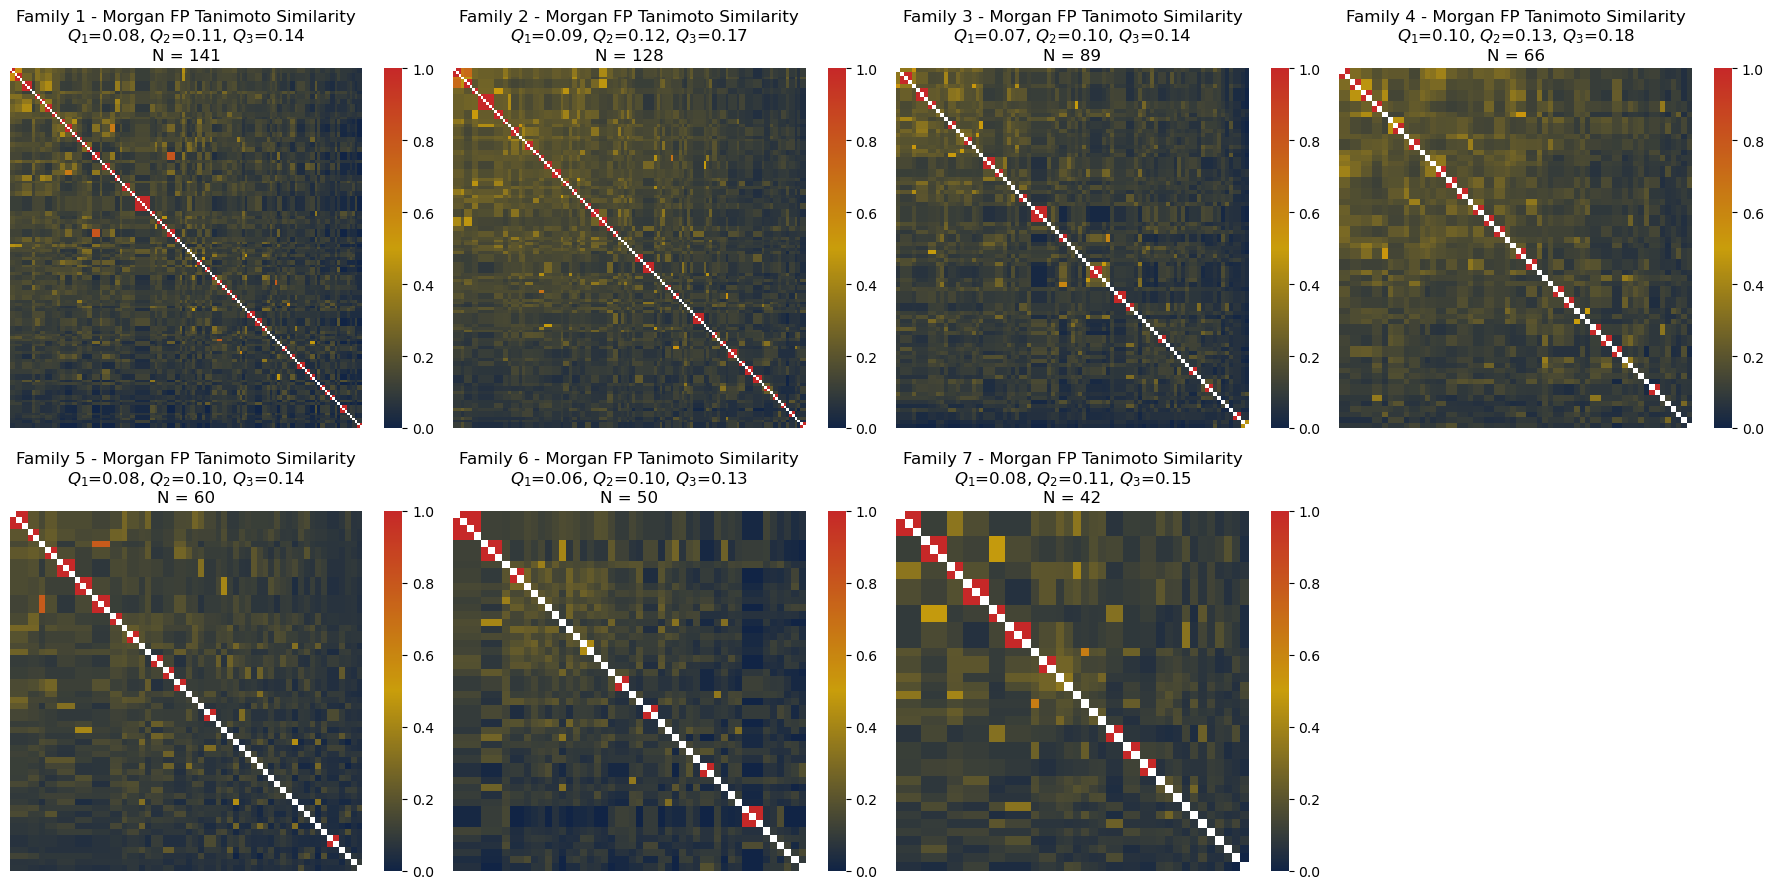

In [16]:
TAR_PATH = Path("./data/mol_prepared_superpose_lig_all.tar.xz")
with tarfile.open(TAR_PATH, "r:xz") as tar:
    superpose_mol_files = [
        m
        for m in tar.getmembers()
        if m.isfile() and not Path(m.name).name.startswith("._")
    ]

sel_sdfs = [
    x
    for x in superpose_mol_files
    if any(member.split("-")[0] in x.name for member in sel_members)
]

print(f"Total files in archive: {len(superpose_mol_files)}")
print(f"Selected subset: {len(sel_sdfs)}")
print("")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes = axes.flatten()
q1_label = r"$Q_1$"
q2_label = r"$Q_2$"
q3_label = r"$Q_3$"
percentiles = []
bs_cmap_short = mcolors.LinearSegmentedColormap.from_list(
    "bs_cmap_short", ["#C62828", "#C99D0B", "#112445"]
)
for i, (clust_label, mems) in tqdm(enumerate(cluster_labels.items())):
    CLUST_IDX = i

    sel_members = np.array([x.split("-")[0] for x in mems])
    sel_size = len(sel_members)

    # print(f"Cluster ID: {sel_id} | Members: {sel_size}")

    sel_sdfs = [
        x
        for x in superpose_mol_files
        if any([member in x.name for member in sel_members])
    ]
    sel_mols = [mols[sm] for sm in sel_members]
    morgan_sim_map, order = morgan_similarity_matrix(sel_mols, return_order=True)
    sel_members = sel_members[order]
    np.fill_diagonal(morgan_sim_map, np.nan)

    q1, q2, q3 = np.nanpercentile(morgan_sim_map, [25, 50, 75])
    percentiles.append([q1, q2, q3])
    title = (
        f"Family {CLUST_IDX + 1} - Morgan FP Tanimoto Similarity\n"
        f"{q1_label}={q1:.2f}, {q2_label}={np.nanmedian(morgan_sim_map):.2f}, "
        f"{q3_label}={q3:.2f}"
        f"\nN = {len(morgan_sim_map)}"
    )

    heatmap(
        morgan_sim_map,
        prov_ax=axes[CLUST_IDX],
        sorted=False,
        title=title,
        title_font=12,
        xticks=[],
        yticks=[],
        tick_font=5,
        cmap=bs_cmap_short,
    )

    axes[CLUST_IDX].tick_params(axis="x", which="both", labelrotation=90)

for ax in axes[len(cluster_labels) :]:
    ax.axis("off")
fig.tight_layout()
fig.savefig("./final_figures/all_cluster_morgan_sim.png", bbox_inches="tight", dpi=200)


# PLIF Cluster Summary
Commputes the frequency of the residue-interaction observed in each family, creates summary figure to identify dominant residue interactions

In [17]:
ruids = list(uid_res_map.keys())
aminos = list(uid_res_map.values())
for ruid, aa in zip(ruids, aminos):
    for chain in [10000, 20000]:
        uid_res_map[ruid + chain] = aa


inv_mapping = {v: k for k, v in mapping.items()}
plif_data = dict()
plif_data["ruids"] = []
plif_data["ints"] = []
plif_data["complexes"] = []
plif_data["lig_id"] = []


for i, fp in enumerate(frag_fps):
    flag_idxs = np.where(fp == 1)[0]
    mappings = np.array([np.array(inv_mapping[j]) for j in flag_idxs])
    mappings = mappings.T
    ruids = mappings[0]
    ints = [PLIF_TYPES[m] for m in mappings[1]]
    complex = [frag_names[i] for j in ints]

    plif_data["complexes"].extend(complex)
    plif_data["ruids"].extend(ruids)
    plif_data["ints"].extend(ints)

    plif_data["lig_id"].extend([frag_lig_ids[i] for j in ints])


plif_df = pd.DataFrame(plif_data)
plif_df["residue"] = [uid_res_map[int(r)] for r in plif_data["ruids"]]


plif_df["fp"] = [
    f"{res} {r}-{i}"
    for res, r, i in zip(plif_df["residue"], plif_df["ruids"], plif_df["ints"])
]
plif_df

,ruids,ints,complexes,lig_id,residue,fp
0,96,ACC SIDE,x0036,x0036-0,HIS,HIS 96-ACC SIDE
1,105,ACC SIDE,x0036,x0036-0,GLN,GLN 105-ACC SIDE
2,97,ACC SIDE,x0036,x0036-1,ARG,ARG 97-ACC SIDE
3,97,ION ATTR.,x0036,x0036-1,ARG,ARG 97-ION ATTR.
4,96,ACC SIDE,x0037,x0037-0,HIS,HIS 96-ACC SIDE
...,...,...,...,...,...,...
1608,197,ARN CON.,x0992,x0992-2,LYS,LYS 197-ARN CON.
1609,132,ARN CON.,x0992,x0992-4,LEU,LEU 132-ARN CON.
1610,133,ACC BACK,x0992,x0992-4,LYS,LYS 133-ACC BACK
1611,173,ACC SIDE,x0992,x0992-4,HIS,HIS 173-ACC SIDE


7it [00:01,  3.90it/s]


,ruids,ints,complexes,lig_id,residue,fp,cluster
0,96,ACC SIDE,x0036,x0036-0,HIS,HIS 96-ACC SIDE,0
1,105,ACC SIDE,x0036,x0036-0,GLN,GLN 105-ACC SIDE,0
2,97,ACC SIDE,x0036,x0036-1,ARG,ARG 97-ACC SIDE,0
3,97,ION ATTR.,x0036,x0036-1,ARG,ARG 97-ION ATTR.,0
25,97,ACC SIDE,x0057,x0057-1,ARG,ARG 97-ACC SIDE,0
...,...,...,...,...,...,...,...
1596,202,DON SIDE,x0987,x0987-1,ASP,ASP 202-DON SIDE,6
1597,202,ION ATTR.,x0987,x0987-1,ASP,ASP 202-ION ATTR.,6
1598,202,DON SIDE,x0987,x0987-3,ASP,ASP 202-DON SIDE,6
1599,202,ION ATTR.,x0987,x0987-3,ASP,ASP 202-ION ATTR.,6


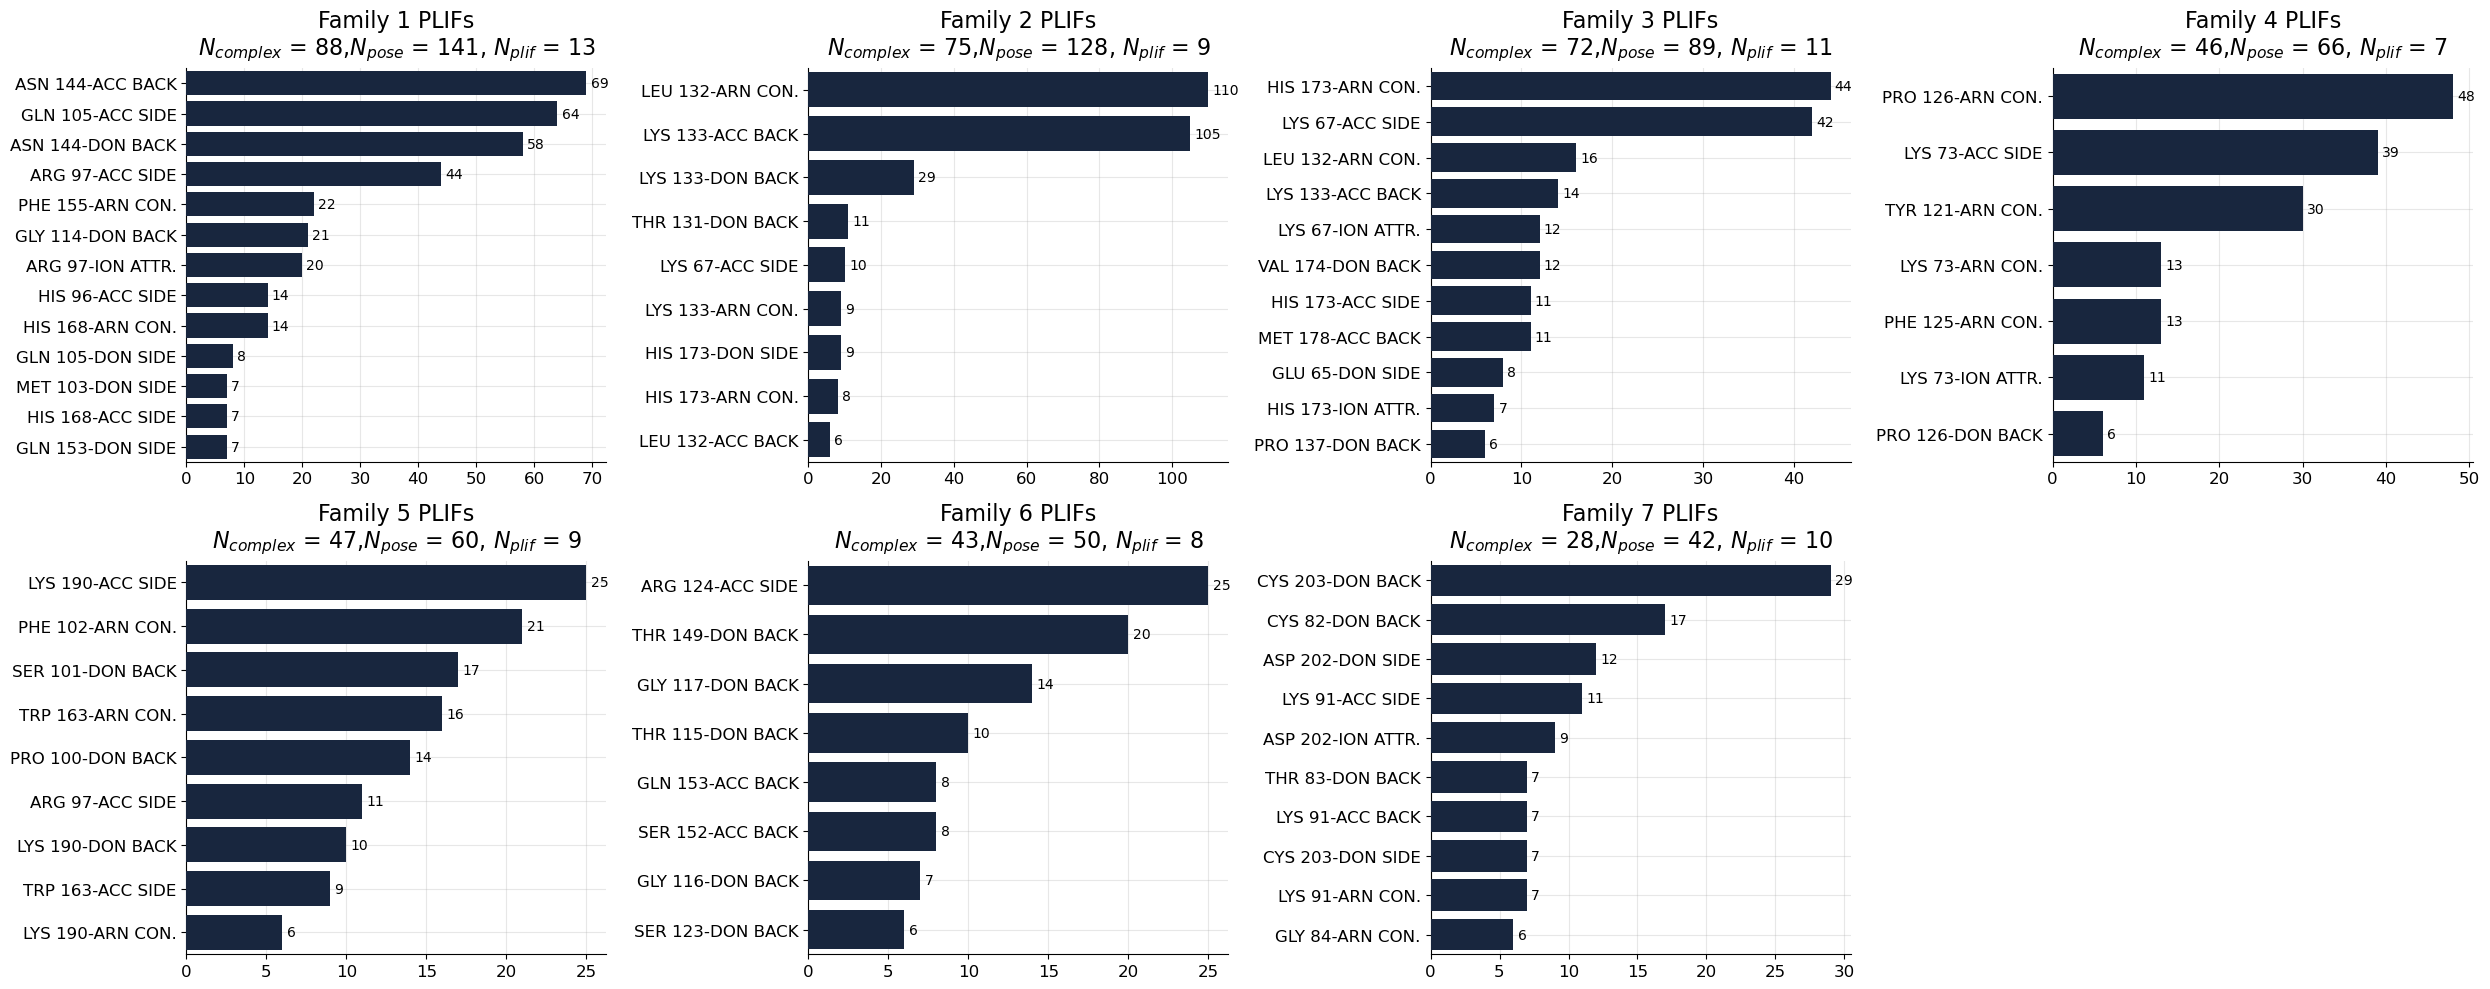

In [18]:
%matplotlib inline
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(25, 10))
axes = axes.flatten()

dfs = []
for i, (clust_label, mems) in tqdm(enumerate(cluster_labels.items())):
    CLUST_IDX = i
    # sel_id = clust_ids[CLUST_IDX]
    # sel_members = frag_names[cluster_labels == sel_id]
    sel_members = mems

    # member_plifs = plif_df[plif_df["complexes"].isin(sel_members)].copy()
    member_plifs = plif_df[plif_df["lig_id"].isin(sel_members)].copy()
    vc = member_plifs["fp"].value_counts().reset_index()
    vc = vc[vc["count"] > 5]
    ax = sns.barplot(
        data=vc,
        x="count",
        y="fp",  # already sorted by count
        color=cmap_hex["dark_blue"],
        ax=axes[CLUST_IDX],
        zorder=5,
    )
    member_plifs.loc[:, "cluster"] = CLUST_IDX
    dfs.append(member_plifs)
    ax.set_title(
        f"Family {CLUST_IDX + 1} PLIFs\n{r'$N_{complex}$'} = {member_plifs['complexes'].nunique()},{r'$N_{pose}$'} = {member_plifs['lig_id'].nunique()}, {r'$N_{plif}$'} = {len(vc)}"
    )
    standardize_graph(ax, tick_size=12, label_size=14, title_size=16, pad=10)
    # add numeric labels to the right of each bar
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt="%.0f", label_type="edge", size=10)

    ax.set_xlabel(None)
    ax.set_ylabel(None)
sns.despine()
for ax in axes[len(cluster_labels) :]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(f"./final_figures/cluster_plifs.png", bbox_inches="tight", dpi=300)
plif_summary_df = pd.concat(dfs, axis=0)
plif_summary_df.to_excel(f"processed_data/per_cluster_plifs.xlsx", index=False)
plif_summary_df